In [1]:
import torch
import torchvision
from torchvision import transforms
from datasets import load_dataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F
from diffusers import DDPMScheduler
from diffusers import UNet2DModel
from PIL import Image

2025-08-30 07:47:54.674632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756540074.841477      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756540074.889715      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
dataset = load_dataset("huggan/smithsonian_butterflies_subset",split='train')

README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [3]:
image_size=64

preprocess=transforms.Compose([
        transforms.Resize((image_size, image_size)), 
        transforms.RandomHorizontalFlip(), 
        transforms.ToTensor(), 
        transforms.Normalize([0.5], [0.5]), 
    ])

In [4]:
dataset.set_transform(preprocess)
batch_size=64
def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

device="cuda" if torch.cuda.is_available() else "cpu"

In [5]:
def show_images(image):
    plt.imshow(make_grid(image*0.5+0.5).permute(1,2,0))

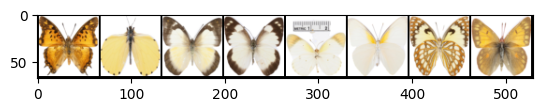

In [6]:
batch=next(iter(train_dataloader))
show_images(batch['images'][:8])

In [7]:
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.001, beta_end=0.02)
model=UNet2DModel(sample_size=64,block_out_channels=(64,128,256,512,512,512,512),
                  down_block_types=('DownBlock2D', 'AttnDownBlock2D', 'AttnDownBlock2D',\
                                    'AttnDownBlock2D','AttnDownBlock2D','AttnDownBlock2D',\
                                    'AttnDownBlock2D'),
                   up_block_types=('AttnUpBlock2D','AttnUpBlock2D','AttnUpBlock2D',\
                                   'AttnUpBlock2D', 'AttnUpBlock2D', 'AttnUpBlock2D',\
                                   'UpBlock2D'))

In [8]:
num_epochs=200
ls=1e-4
model=model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=ls)
losses = []

for epoch in range(num_epochs):
    for step, batch in enumerate(train_dataloader):

        clean_images = batch["images"].to(device)

        noise = torch.randn(clean_images.shape).to(clean_images.device)
        timesteps = torch.randint(
            0,
            scheduler.num_train_timesteps,
            (clean_images.shape[0],),
            device=clean_images.device,
        ).long()

        noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        loss = F.mse_loss(noise_pred, noise)

        losses.append(loss.item())
        loss.backward(loss)
        optimizer.step()
        optimizer.zero_grad()
    if (epoch+1)%10==0:
        print(f"Epoch {epoch+1} Loss {loss}")

/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch 10 Loss 0.0945398360490799
Epoch 20 Loss 0.06216457113623619
Epoch 30 Loss 0.05752918869256973
Epoch 40 Loss 0.033732518553733826
Epoch 50 Loss 0.04646018519997597
Epoch 60 Loss 0.02894032560288906
Epoch 70 Loss 0.03544045612215996
Epoch 80 Loss 0.03173385560512543
Epoch 90 Loss 0.03257599100470543
Epoch 100 Loss 0.018739327788352966
Epoch 110 Loss 0.02159629389643669
Epoch 120 Loss 0.017857778817415237
Epoch 130 Loss 0.016702156513929367
Epoch 140 Loss 0.016952911391854286
Epoch 150 Loss 0.023755820468068123
Epoch 160 Loss 0.021197952330112457
Epoch 170 Loss 0.02534879744052887
Epoch 180 Loss 0.020747780799865723
Epoch 190 Loss 0.014876442030072212
Epoch 200 Loss 0.01822449266910553


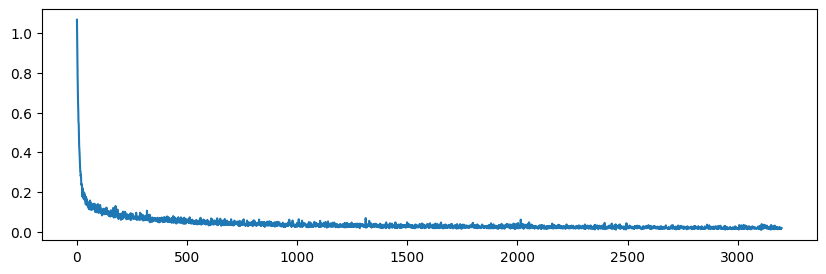

In [9]:
plt.figure(figsize=(10,3))
plt.plot(losses)

In [10]:
from diffusers import DDPMPipeline

pipe= DDPMPipeline(unet=model,scheduler=scheduler)
pipe.to(device)

DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.34.0",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

  0%|          | 0/1000 [00:00<?, ?it/s]

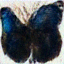

In [11]:
spipe().images[0]